**Full Data PreProcessing Project**
- Dataset - Loan Approval Dataset
This Notebook demonstrates a complete data preprocessing pipeline for a loan approval dataset including:
- Loading and Cleaning Data
- Handling Missing Values
- Outlier Treatment
- Encoding Categorical Features
- Handling Imbalanced Data
- Feature Scaling

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder,StandardScaler

from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns",None)
pd.set_option("display.float_format","{:.3f}".format)


### **1. Data Loading and Basic Cleanup**

In [139]:
df = pd.read_csv("loan.csv")
print("Shape of the dataset:", df.shape)
print("Columns in Dataset:",df.columns.to_list())
df.head()

Shape of the dataset: (614, 13)
Columns in Dataset: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.000,NaN,360.000,1.000,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.000,128.000,360.000,1.000,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.000,66.000,360.000,1.000,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.000,120.000,360.000,1.000,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.000,141.000,360.000,1.000,Urban,Y


In [140]:
df.columns = [col.lower() for col in df.columns]
df.columns

Index(['loan_id', 'gender', 'married', 'dependents', 'education',
       'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status'],
      dtype='str')

In [141]:
df.drop(columns=["loan_id"])

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,Male,No,0,Graduate,No,5849,0.000,NaN,360.000,1.000,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.000,128.000,360.000,1.000,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.000,66.000,360.000,1.000,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.000,120.000,360.000,1.000,Urban,Y
4,Male,No,0,Graduate,No,6000,0.000,141.000,360.000,1.000,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.000,71.000,360.000,1.000,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.000,40.000,180.000,1.000,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.000,253.000,360.000,1.000,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.000,187.000,360.000,1.000,Urban,Y


In [142]:
target= "loan_status"

In [143]:
df[target] = df[target].map({"Y" : 1,"N" : 0})

In [144]:
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.000,NaN,360.000,1.000,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.000,128.000,360.000,1.000,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.000,66.000,360.000,1.000,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.000,120.000,360.000,1.000,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.000,141.000,360.000,1.000,Urban,1


### **2. Train Test Split**

In [145]:
X = df.drop(columns=[target])
y = df[target]

In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y
)

In [147]:

X_train.drop(columns =["loan_id"])

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
154,Male,No,0,Graduate,No,3254,0.000,50.000,360.000,1.000,Urban
239,Male,Yes,1,Graduate,No,3315,0.000,96.000,360.000,1.000,Semiurban
448,Male,Yes,2,Graduate,No,3340,1710.000,150.000,360.000,0.000,Rural
471,Male,Yes,1,Not Graduate,No,2653,1500.000,113.000,180.000,0.000,Rural
273,Male,Yes,0,Graduate,No,2620,2223.000,150.000,360.000,1.000,Semiurban
...,...,...,...,...,...,...,...,...,...,...,...
222,Male,No,0,Graduate,No,2971,2791.000,144.000,360.000,1.000,Semiurban
349,Male,Yes,0,Graduate,No,2625,6250.000,187.000,360.000,1.000,Rural
26,Male,Yes,0,Graduate,No,2799,2253.000,122.000,360.000,1.000,Semiurban
96,Female,Yes,0,Graduate,No,2484,2302.000,137.000,360.000,1.000,Semiurban


In [148]:
X_train = X_train.drop(columns= ["loan_id"])


In [149]:
print(X_train.columns)

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area'],
      dtype='str')


In [150]:
print("Train Shape:",X_train.shape)
print("Test Shape:",X_test.shape)

Train Shape: (491, 11)
Test Shape: (123, 12)


In [151]:
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

### **3. Identify Numerical and Categorical Column**

In [152]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["str"]).columns.tolist()

print("Numerical Columns:",num_cols)
print("Categorical Columns:",cat_cols)

Numerical Columns: ['applicantincome', 'coapplicantincome', 'loanamount', 'loan_amount_term', 'credit_history']
Categorical Columns: ['gender', 'married', 'dependents', 'education', 'self_employed', 'property_area']


### **4. Handling Missing Values**

In [153]:
if num_cols:
    num_imputer = SimpleImputer(strategy="median")
    X_train_processed[num_cols] = num_imputer.fit_transform(X_train_processed[num_cols])
    X_test_processed[num_cols] = num_imputer.fit_transform(X_test_processed[num_cols])

if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_train_processed[cat_cols] = cat_imputer.fit_transform(X_train_processed[cat_cols])
    X_test_processed[cat_cols] = cat_imputer.fit_transform(X_test_processed[cat_cols])

print("Missing values in training Set:",X_train_processed.isnull().sum())
print("Missing values in test Set:",X_test_processed.isnull().sum())

Missing values in training Set: gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64
Missing values in test Set: loan_id              0
gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64


### **5. Outlier Treatment**

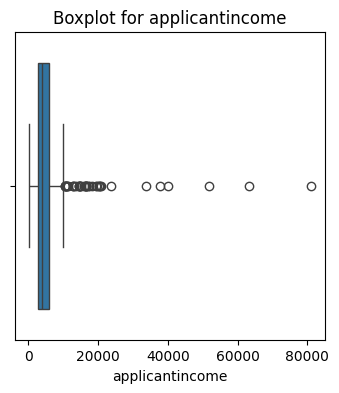

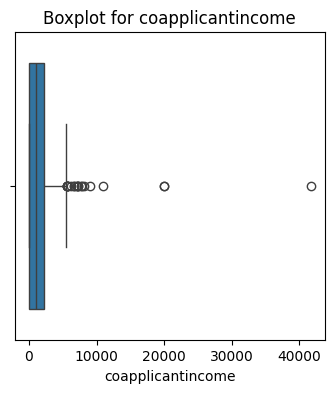

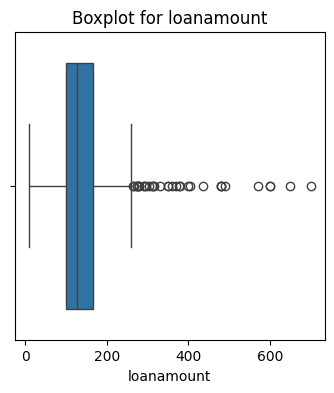

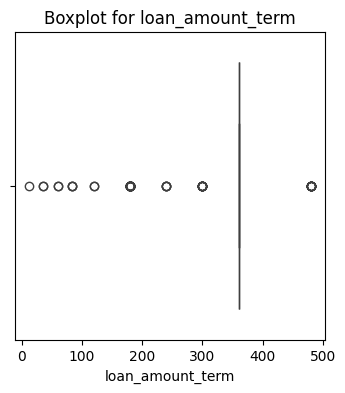

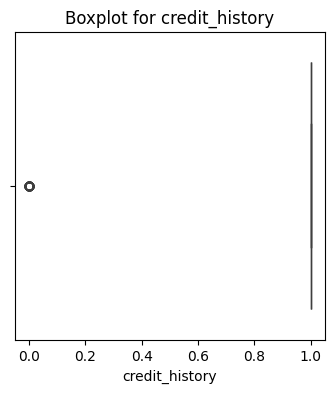

In [154]:
for col in num_cols:
    plt.figure(figsize=(4,4))
    sns.boxplot(x= X_train_processed[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

**Outlier Treatment Decision**
**Numerical Columns**
- applicantincome
- coapplicantincome
- loanamount
- loan_amount_term
- credit_history
---
Outlier Capping Decision

|Column | Cap Outliers? | Reason |
|-------|---------------|--------|
|applicantincome | Yes | Continuous feature with strong right skew and extreme values |
|coapplicantincome | Yes | Many zeroes and few Large values causing Skew |
|loanamount | Yes | Large Loan Values can dominate Model Learning |
|loan_amount_term | No | Descrete, domain-valid Values like 120,180,240,360
|Credit_History | No | Binary Feature(0 or 1). Outliers do not exist. |
---
**Final Rule of thumb**
- Apply outlier treatment only to continuous numerical features.
- Do not cap Binary or discrete numerical columns.
- Always handle missing values before Outlier Treatment.

Note: Outlier Capping is required only where extreme values distort the data distribution.

In [155]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - IQR*1.5
    upper = Q3 + IQR*1.5
    return lower, upper

def compute_train_bounds(df,cols):
    bounds = {}
    for col in cols:
        low, high = iqr_bounds(df[col])
        bounds[col] = (low, high)
    return bounds

def cap_outliers_with_bounds(df, bounds):
    df_capped = df.copy()
    for col, (low, high) in bounds.items():
        df_capped[col] = np.where(df_capped[col] < low, low, df_capped[col])
        df_capped[col] = np.where(df_capped[col] > high, high, df_capped[col])
    return df_capped

In [156]:
X_train_processed.columns

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area'],
      dtype='str')

In [157]:
outlier_cols = ["applicantincome","coapplicantincome","loanamount"]
train_bounds = compute_train_bounds(X_train_processed,outlier_cols)

In [158]:
train_bounds

{'applicantincome': (np.float64(-1472.5), np.float64(10203.5)),
 'coapplicantincome': (np.float64(-3361.5), np.float64(5602.5)),
 'loanamount': (np.float64(3.75), np.float64(261.75))}

In [159]:
X_train_processed[outlier_cols] = cap_outliers_with_bounds(X_train_processed[outlier_cols],train_bounds)
X_test_processed[outlier_cols] = cap_outliers_with_bounds(X_test_processed[outlier_cols],train_bounds)

### **6. Encoding Categorical Columns**

In [160]:
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

In [172]:
from sklearn.impute import SimpleImputer

cat_cols = ["gender", "married", "dependents", "self_employed"]

imputer = SimpleImputer(strategy="most_frequent")

X_train_processed[cat_cols] = imputer.fit_transform(
    X_train_processed[cat_cols]
)

X_test_processed[cat_cols] = imputer.transform(
    X_test_processed[cat_cols]
)

**Label Encoding**

In [173]:
for col in cat_cols:
    print(col,X_train_processed[col].unique().tolist())
    print("-" * 20)

gender [1, 0, 2]
--------------------
married [0, 1]
--------------------
dependents [0, 1, 2, 4, 3]
--------------------
self_employed [0, 1, 2]
--------------------


**Note: here,only one column is multi-class nominal - property_area(needs one-hot encoding), others are binary/ordinal.So let's use only Label Encoding for Simplicity.Based on model performance we can try one-hot encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()

    X_train_processed[col] = X_train_processed[col].astype(str)
    X_test_processed[col] = X_test_processed[col].astype(str)

    le.fit(X_train_processed[col])

    label_encoders[col] = le

    X_train_processed[col] = le.transform(X_train_processed[col])
    X_test_processed[col] = le.transform(X_test_processed[col])

In [176]:
print(label_encoders)

{'gender': LabelEncoder(), 'married': LabelEncoder(), 'dependents': LabelEncoder(), 'self_employed': LabelEncoder()}


In [177]:
X_train_processed[cat_cols].head()

,gender,married,dependents,self_employed
154,1,0,0,0
239,1,1,1,0
448,1,1,2,0
471,1,1,1,0
273,1,1,0,0


In [178]:
X_train_processed.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
154,1,0,0,0,0,3254,0.000,50.000,360.000,1.000,2
239,1,1,1,0,0,3315,0.000,96.000,360.000,1.000,1
448,1,1,2,0,0,3340,1710.000,150.000,360.000,0.000,0
471,1,1,1,1,0,2653,1500.000,113.000,180.000,0.000,0
273,1,1,0,0,0,2620,2223.000,150.000,360.000,1.000,1


### **7. Handle imbalanced Data**

In [179]:
print(y_train.value_counts())
print(y_train.value_counts(normalize= True))

print("-" * 50)

print(y_test.value_counts())
print(y_test.value_counts(normalize= True))

loan_status
1    337
0    154
Name: count, dtype: int64
loan_status
1   0.686
0   0.314
Name: proportion, dtype: float64
--------------------------------------------------
loan_status
1    85
0    38
Name: count, dtype: int64
loan_status
1   0.691
0   0.309
Name: proportion, dtype: float64


In [182]:
print("Total NaNs:", X_train_processed.isna().sum().sum())

print("\nColumns with NaNs:")
print(X_train_processed.isna().sum()[X_train_processed.isna().sum() > 0])

Total NaNs: 75

Columns with NaNs:
loanamount          20
loan_amount_term    12
credit_history      43
dtype: int64


In [183]:
print(X_train_processed.info())

<class 'pandas.DataFrame'>
Index: 491 entries, 154 to 354
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             491 non-null    int64  
 1   married            491 non-null    int64  
 2   dependents         491 non-null    int64  
 3   education          491 non-null    int64  
 4   self_employed      491 non-null    int64  
 5   applicantincome    491 non-null    int64  
 6   coapplicantincome  491 non-null    float64
 7   loanamount         471 non-null    float64
 8   loan_amount_term   479 non-null    float64
 9   credit_history     448 non-null    float64
 10  property_area      491 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 46.0 KB
None


In [184]:
from sklearn.impute import SimpleImputer

# Median imputation
median_cols = ["loanamount", "loan_amount_term"]

median_imputer = SimpleImputer(strategy="median")

X_train_processed[median_cols] = median_imputer.fit_transform(
    X_train_processed[median_cols]
)

X_test_processed[median_cols] = median_imputer.transform(
    X_test_processed[median_cols]
)

# Mode imputation
mode_imputer = SimpleImputer(strategy="most_frequent")

X_train_processed[["credit_history"]] = mode_imputer.fit_transform(
    X_train_processed[["credit_history"]]
)

X_test_processed[["credit_history"]] = mode_imputer.transform(
    X_test_processed[["credit_history"]]
)

In [186]:
print(X_train_processed.isna().sum())
print("Total NaNs:", X_train_processed.isna().sum().sum())

gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64
Total NaNs: 0


In [187]:
smote = SMOTE(random_state=42)

In [188]:
#Should be balanced only on training set
X_train_processed,y_train_processed = smote.fit_resample(X_train_processed, y_train)

In [189]:
print(y_train_processed.value_counts())
print(y_train_processed.value_counts(normalize= True))

print("-" * 100)

print(y_test.value_counts())
print(y_test.value_counts(normalize= True))

loan_status
1    337
0    337
Name: count, dtype: int64
loan_status
1   0.500
0   0.500
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
loan_status
1    85
0    38
Name: count, dtype: int64
loan_status
1   0.691
0   0.309
Name: proportion, dtype: float64


### **8. Standardization - Standard Scaler**

In [190]:
scaler = StandardScaler()

In [191]:
scale_cols = ["applicantincome", "coapplicantincome", "loanamount", "loan_amount_term"]

In [194]:
scaler.fit(X_train_processed[scale_cols])
X_train_processed[scale_cols] = scaler.transform(X_train_processed[scale_cols])
X_test_processed[scale_cols] = scaler.transform(X_test_processed[scale_cols])

In [195]:
X_train_processed.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
0,1,0,0,0,0,-0.379,-0.595,-1.208,0.268,1.000,2
1,1,1,1,0,0,-0.368,-0.595,-0.636,0.268,1.000,1
2,1,1,2,0,0,-0.364,0.076,0.037,0.268,0.000,0
3,1,1,1,1,0,-0.483,-0.006,-0.424,-2.660,0.000,0
4,1,1,0,0,0,-0.489,0.278,0.037,0.268,1.000,1


In [197]:
print("\nFinal Shape:")
print("X_train_processed shape:",X_train_processed.shape)
print("X_test_processed shape:",X_test_processed.shape)
print("y_train_processed Shpe:",y_train_processed.shape)
print("y_test shape          :",y_test.shape)


Final Shape:
X_train_processed shape: (674, 11)
X_test_processed shape: (123, 12)
y_train_processed Shpe: (674,)
y_test shape          : (123,)
